# Data Visualization Tools
Helps visualize some important data

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

In [155]:
def parse_file(path:str):
    '''
    Parse a eval log to get the class data

    Args:
        path: string representing path to log

    Returns:
        Pandas DataFrame with columns representing the IoU and Acc
    '''
    raw=''
    with open(path) as f:
        # parse raw data
        raw = f.read().split('\n')[47:-5]
        for i in range(len(raw)):
            entry = raw[i].split(', ')[1:]
            entry = np.array([x.split(': ')[1] for x in entry])
            entry[1] = entry[1][:-1]
            raw[i] = ', '.join(entry)
        data = ['IoU, Acc'] + raw
        raw = '\n'.join(data)
    out = pd.read_csv(io.StringIO(raw))
    out['IoU'] = out['IoU']*100
    return out

<Axes: >

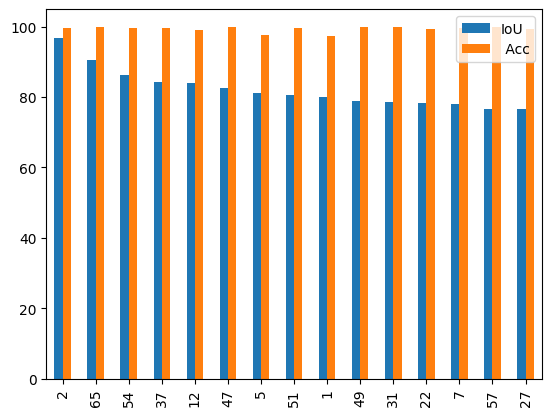

In [169]:
df = parse_file('./eval/eval_0.0.txt')
df=df.loc[df.iloc[:,0]!=0.0]
df.nlargest(n=15, columns=df.columns[0]).plot.bar()

<Axes: xlabel='Ratio'>

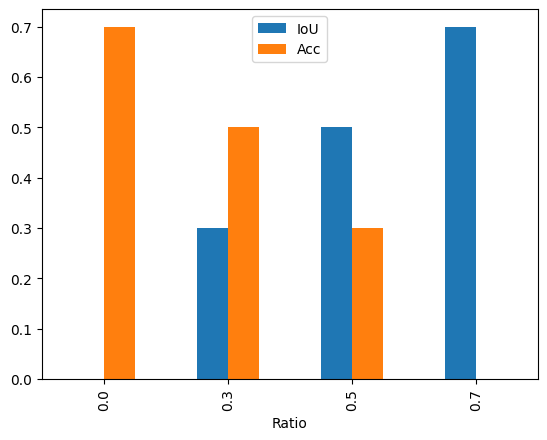

In [164]:
df={
    "Ratio": [0.0, 0.3, 0.5, 0.7],
    "IoU": [0.0, 0.3, 0.5, 0.7],
    "Acc": [0.7, 0.5, 0.3, 0.]
}

df = pd.DataFrame(df)
df.plot.bar(x=df.columns[0])

In [185]:
def plot_IoU(r:float, fine=False):
    '''
    Plots the IoU for a specific data set

    Args:
        r: desired pruning ratio
        fine: plot fine tunned version or not

    Return:
        None
    '''
    path = f'./eval/eval_{r}'
    path += '_fine.txt' if fine else '.txt'
    
    df = parse_file(path)
    df=df.loc[df.iloc[:,0]!=0.0]
    df.nlargest(n=15, columns=df.columns[0]).plot.bar(y=df.columns[0], ylim=(0,100))
    plt.title(f'IoU for pruning ratio {r} and fine-tunning={fine}')

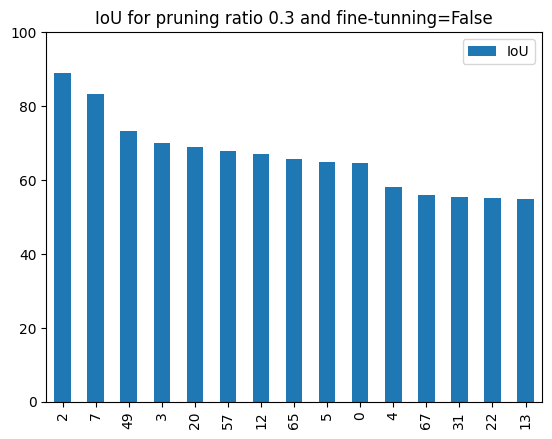

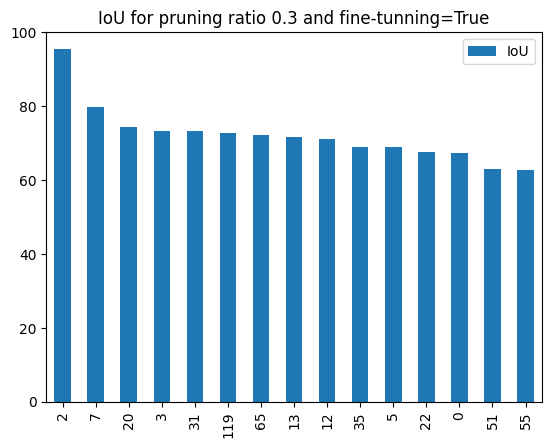

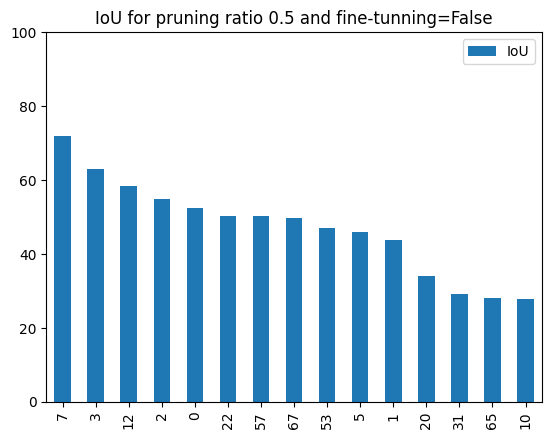

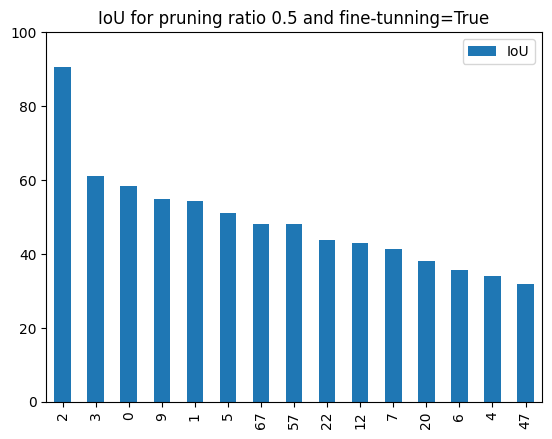

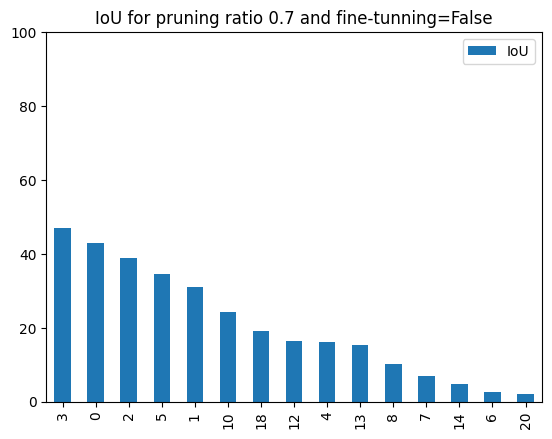

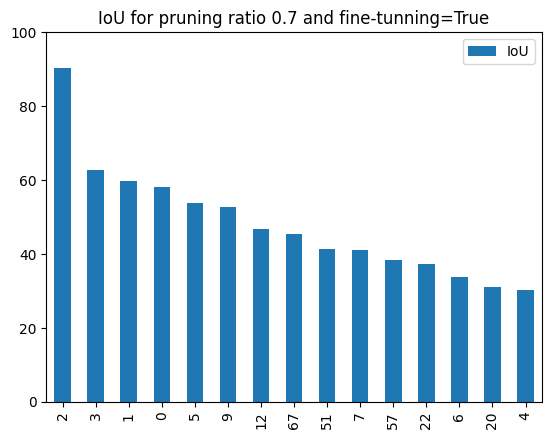

In [190]:
ratios = [0.3, 0.5, 0.7]

for r in ratios:
    plot_IoU(r, False)
    plt.savefig(f'plots/{r}_false.png')
    plot_IoU(r, True)
    plt.savefig(f'plots/{r}_true.png')

In [ ]:
Mean IoU: 0.0701, Accuracy: 61.51%
mNotFine = {
    "Ratio": [0.0, 0.3, 0.5, 0.7],
    "Mean IoU": [25.57, 13.12, 6.36, 2.11],
    "Mean Acc": [82.76, 69.31, 53.17, 41.04]
          }

mFine = {
    "Ratio": [0.0, 0.3, 0.5],
    "Mean IoU": [25.57, 16.76, 6.82, 7.01],
    "Mean Acc": [82.76, 74.17, 61.29, 61.51]
          }